# DAU 차트를 봐서는 DAU를 올릴 수 없다 — 유저 세그먼트 분석 실습

DAU 한 줄짜리 그래프로는 신규 유저의 안착도, 헤비 유저의 이탈 징후도, 잠들었던 유저의 부활도
모두 한 점으로 뭉개져 보이지 않습니다. 이 노트북은 가상의 습관 트래커 앱 ‘루틴로그’의 유저를 **5개 세그먼트**로 쪼개고,
세그먼트 사이의 **이동(Flow)** 과 비율 지표로 서비스 건강도를 입체적으로 들여다봅니다.
그림과 표가 꽤나 복잡해 보이지만, 막상 SQL로 옮겨 보면 의외로 단순한 데이터 구조 위에서
돌아간다는 사실을 확인할 수 있습니다.

분석은 두 개의 원천 테이블에서 출발합니다.

| 테이블 | 입자 단위 | 역할 |
| :-- | :-- | :-- |
| `user_master` | user_id (유저당 1행) | 유저별 가입(첫 기록) 정보 — 언제 처음 우리 서비스를 만났는가 |
| `user_activity` | user_id × event_date | 유저가 습관 체크를 남긴 날의 기록 — 어느 날 서비스를 실제로 썼는가 |

- **실습 1.** 두 테이블에서 3개 파생지표(`days_since_signup`, `active_day_count`, `last_active_date`)를 만들고, 정해진 기준에 따라 5개 세그먼트(new / heavy / light / risk / dormant)로 분류합니다. 세그먼트에 ‘오늘 기록 여부’를 교차해 DAU 구성도 확인합니다.
- **실습 2.** 날짜 × 유저 단위의 세그먼트 스냅샷을 한 달치 쌓고, 어제 세그먼트를 `lag` 로 나란히 붙여 세그먼트 변화를 추적할 수 있는 마트를 만듭니다.
- **실습 3.** 그 마트를 분포(Stock) · 전이 행렬(Flow) · 비율 지표(HURR/CURR/Heavy Loss/Light Loss/Reactivation) 세 각도로 분석합니다.
- **실습 4.** 한 달치 마트를 self-join 해, 30일 전 heavy 유저와 new 유저가 오늘 어디로 흩어졌는지 N일 변화를 추적합니다.

쿼리는 모두 **DuckDB**로 예시 CSV에 직접 실행합니다.

## 0. 실습용 데이터 준비

아래 첫 셀은 의존성을 설치하고, 다음 셀이 실습 환경(연결·기준일 상수·테이블 등록)을 구성합니다.
데이터가 없다면 먼저 터미널에서 `python generate_data.py` 를 실행해 예시 데이터를
만들어 주세요 (`data/user_master.csv`, `data/user_activity.csv`).

> **[내 데이터 적용]** 분석 기준일은 `TARGET` 상수 한 곳만 내 날짜로 바꿉니다. 각 쿼리가
> f-string 으로 이 값을 끼워 넣고, 실습 2의 적재 날짜 범위도 여기서 유도됩니다.

### 두 테이블: user_master 와 user_activity

실습에는 유저별 가입 정보가 기록된 `user_master` 와, 유저의 행동 로그가 기록된
`user_activity` 두 테이블이 필요합니다. 굳이 두 테이블로 분리해 두는 이유는, 담고 있는
데이터의 성격이 다르기 때문입니다. 첫 기록일은 유저당 한 번만 기록되는 정적 마스터
테이블이고, 일별 기록은 매일 새로 쌓이는 로그 테이블입니다. 루틴로그에서 ‘활동’은 접속이
아니라 그날 습관 체크를 남긴 것이므로, `user_activity` 의 한 행은 ‘어느 유저가 어느 날
기록을 남겼다’를 뜻합니다. 갱신 주기도, 사용되는 맥락도
다른 두 데이터를 한 테이블에 한꺼번에 담지 않는 편이 마트 운영과 분석 모두에 더 유리합니다.

두 CSV는 아래 셀에서 DuckDB 테이블로 등록해 두고, 이후 모든 쿼리에서 테이블 이름으로
참조합니다. 분석 기준일은 `TARGET` 상수 한 곳에 두고, 각 SQL에는 파이썬 f-string으로 끼워 넣습니다(`DATE '{TARGET}'`). 기준일을 바꾸려면 이 상수만 고치면 되고, 실습 2의 적재 날짜 범위도 여기서 유도됩니다. DuckDB는 별도 서버 설치 없이 파이썬 안에서 바로 SQL을 돌릴 수 있는 가벼운
분석용 DB인데요. 여기서 쓰는 SQL은 거의 표준 문법이라, 사내 웨어하우스(BigQuery,
Redshift 등)로 옮길 때도 함수 몇 개만 손보면 됩니다.

> **[내 데이터 적용]** 내 서비스의 두 테이블로 바꿉니다 —
> `user_master(user_id, first_active_date)`, `user_activity(user_id, event_date)`.

In [ ]:
# 의존성 설치
%pip install -q -r requirements.txt

In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()   # 인메모리 연결 하나를 노트북 전체에서 재사용
SEG_ORDER = ["new", "heavy", "light", "risk", "dormant"]
TARGET = "2026-05-20"    # 분석 기준일

# CSV 두 개를 테이블로 한 번만 등록 — 이후 쿼리는 테이블 이름으로 참조
for t in ["user_master", "user_activity"]:
    q = f"CREATE TABLE {t} AS SELECT * FROM read_csv_auto('data/{t}.csv')"
    con.execute(q)
con.execute("SELECT * FROM user_activity").df().head()

,user_id,event_date
0,user_032,2026-01-27
1,user_144,2026-01-27
2,user_144,2026-01-28
3,user_123,2026-01-29
4,user_144,2026-01-29


## 실습 1. 3개의 파생지표로 5개 세그먼트 분류하기

`user_master` 혹은 `user_activity` 테이블만 살펴봐서는 개별 유저가 어떤 세그먼트에
속하는지 파악하기 어렵습니다. 이 두 테이블은 어디까지나 분석을 위한 기초 데이터일 뿐이고,
세그먼트 구분을 위해서는 한 단계의 가공이 더 필요합니다.

5개 세그먼트(new, heavy, light, risk, dormant)는 다음 3개의 축으로 결정됩니다.

| 축 | 의미 |
| :-- | :-- |
| `days_since_signup` | 가입(첫 기록) 후 며칠째인가? |
| `active_day_count` | 최근 7일 중 며칠 기록했는가? |
| `last_active_date` | 가장 최근 기록일은? |

세그먼트 정의에는 들어가지 않지만 ‘오늘 기록했는가’(`d0_active`)도 같이 만들어 둡니다.
뒤에서 세그먼트별 DAU 구성을 볼 때 씁니다.


### 1.1. 파생지표 계산

`user_master` 와 `user_activity` 를 `LEFT JOIN` 한 뒤 유저 단위로 집계하면 파생지표를
한번에 만들 수 있습니다. 결과는 `user_metrics` 테이블에 담아 두고, 다음 단계의 분류 쿼리가
이 테이블을 입력으로 씁니다.

쿼리에 나오는 `count_if` 는 '조건을 만족하는 행이 몇 개인가'를 세는 DuckDB 집계 함수입니다
(BigQuery의 `COUNTIF`, Snowflake의 `COUNT_IF` 와 같은 역할). 사내 데이터 웨어하우스에 이런 함수가
없다면 `SUM(CASE WHEN … THEN 1 ELSE 0 END)` 로 바꿔 쓰면 됩니다. 오늘 기록 여부(`d0_active`)도
비슷한 방식으로 `MAX(CASE WHEN …)` 를 써서 0/1 플래그로 만듭니다.


In [3]:
# 파생지표 — user_master 와 user_activity 를 LEFT JOIN 해 유저 단위로 집계
con.execute(f"""
CREATE OR REPLACE TABLE user_metrics AS
SELECT
  m.user_id,
  -- 1. 가입(첫 기록) 후 며칠째인가 (가입 당일 = 0)
  datediff('day', m.first_active_date, DATE '{TARGET}') AS days_since_signup,
  -- 2. 최근 7일(기준일 포함) 기록 일수
  count_if(a.event_date BETWEEN DATE '{TARGET}' - INTERVAL 6 DAY
                            AND DATE '{TARGET}') AS active_day_count,
  -- 3. 마지막 기록일 (가입 당일 기록이 보장되므로 항상 존재)
  max(CASE WHEN a.event_date <= DATE '{TARGET}'
      THEN a.event_date END) AS last_active_date,
  -- (+) 오늘 기록 여부
  max(CASE WHEN a.event_date = DATE '{TARGET}'
      THEN 1 ELSE 0 END) AS d0_active
FROM user_master m LEFT JOIN user_activity a USING (user_id)
GROUP BY m.user_id, m.first_active_date
""")
con.execute("SELECT * FROM user_metrics ORDER BY user_id").df().head()

,user_id,days_since_signup,active_day_count,last_active_date,d0_active
0,user_001,0,1.0,2026-05-20,1
1,user_002,0,1.0,2026-05-20,1
2,user_003,0,1.0,2026-05-20,1
3,user_004,0,1.0,2026-05-20,1
4,user_005,0,1.0,2026-05-20,1


### 1.2. Segment 매핑

이제 위에서 만든 `user_metrics` 의 3개 지표를 **정해진 기준**에 따라 `CASE WHEN` 한 단계로
5개 세그먼트로 분류합니다. 분류 기준은 다음과 같습니다.

| 세그먼트 | 분류 기준 |
| :-- | :-- |
| `new` | 가입 후 7일 이내 (`days_since_signup < 7`) |
| `heavy` | 가입 8일차 이상 & 최근 7일 중 5일 이상 기록 |
| `light` | 가입 8일차 이상 & 최근 7일 중 1~4일 기록 |
| `risk` | 최근 7일 기록 0일 & 마지막 기록 7~30일 전 |
| `dormant` | 최근 7일 기록 0일 & 마지막 기록 30일 초과 |

> new 를 하루가 아니라 7일로 잡은 이유 — 가입 첫 주는 서비스를 익히는 기간이라 하루하루의
> 기록 여부보다 ‘첫 주를 지나서도 남아 있는가’가 중요합니다. 7일이 지나면 지난 일주일의
> 기록 일수에 따라 heavy/light 로, 기록이 없었다면 risk 로 자연스럽게 넘어갑니다.
>
> risk·dormant 분기는 마지막 기록일만으로 가릅니다 — `active_day_count = 0` 이면
> 최근 7일 기록이 없다는 뜻이라, ‘마지막 기록이 7일 이전인지’를 따로 검사할 필요가 없기
> 때문입니다.


In [4]:
# 정해진 기준에 따라 5개 세그먼트로 분류 — 입력은 user_metrics
seg = con.execute(f"""
SELECT
  *,
  CASE
    WHEN days_since_signup < 7           THEN 'new'
    WHEN active_day_count >= 5           THEN 'heavy'
    WHEN active_day_count BETWEEN 1 AND 4 THEN 'light'
    -- active_day_count = 0 이면 최근 7일 기록이 없다는 뜻이므로,
    -- risk/dormant 는 마지막 기록일이 30일 안쪽인지로만 가르면 된다.
    WHEN last_active_date >= DATE '{TARGET}' - INTERVAL 30 DAY THEN 'risk'
    ELSE 'dormant'
  END AS user_seg
FROM user_metrics
ORDER BY user_id;
""").df()
print(seg["user_seg"].value_counts().reindex(SEG_ORDER))

user_seg
new        16
heavy      39
light      72
risk       53
dormant    20
Name: count, dtype: int64


5개 세그먼트가 모두 등장하도록 각 세그먼트에서 한 명씩 뽑아 보면, 3개 지표가
어떻게 하나의 세그먼트로 압축되는지 한눈에 들어옵니다.

In [5]:
# 각 세그먼트의 대표 유저를 한 명씩 발췌
sample = seg.groupby("user_seg").first().reindex(SEG_ORDER).reset_index()
sample[["user_seg", "user_id", "days_since_signup",
        "active_day_count", "last_active_date"]]

,user_seg,user_id,days_since_signup,active_day_count,last_active_date
0,new,user_001,0,1.0,2026-05-20
1,heavy,user_017,44,6.0,2026-05-20
2,light,user_018,54,1.0,2026-05-19
3,risk,user_021,87,0.0,2026-04-22
4,dormant,user_026,65,0.0,2026-04-16


세그먼트 정의 어디에도 ‘오늘 기록했는가’가 들어 있지 않은데, 그럼 DAU는 어디로 갔을까요?
세그먼트에 오늘의 기록 여부(`d0_active`)를 교차해 보면 됩니다. 오른쪽 열의 합이 오늘의 DAU 입니다.
같은 DAU 라도 heavy 가 채운 날과 new 가 채운 날은 전혀 다른 하루라는 것을, 이 표 하나로 볼 수 있습니다.


In [6]:
# 세그먼트별 오늘 기록 유저 수 — Stock 위에 DAU 를 얹어 본다
dau_by_seg = (seg.groupby("user_seg")
              .agg(users=("user_id", "count"),
                   active_today=("d0_active", "sum"))
              .reindex(SEG_ORDER))
dau_by_seg.loc["total"] = dau_by_seg.sum()
dau_by_seg.astype(int)

,users,active_today
user_seg,,
new,16,11
heavy,39,30
light,72,29
risk,53,0
dormant,20,0
total,200,70


## 실습 2. 세그먼트 변화 추적 가능한 데이터 마트 만들기

실습 1의 결과는 어느 한 시점의 스냅샷, 즉 **Stock** 에 해당합니다. 이 테이블이 있으면 기준
시점에 유저들이 각 세그먼트에 어떻게 분포돼 있는지를 확인할 수 있습니다. 하지만 아래와 같은
질문에 답하려면, **어제와 오늘 두 시점의 세그먼트를 한 행에 나란히 담아둔 데이터 마트**가
필요합니다.

1. 어제 heavy였던 유저 중 몇 명이 오늘 light로 떨어졌는가? (Heavy Loss)
2. 어제 risk였던 유저 중 누가 오늘 다시 활동으로 돌아왔는가? (Reactivation)
3. 어제 heavy였던 유저는 오늘도 heavy로 잘 남아 있는가? (HURR)
4. 가입 8일째를 맞은 new 유저는 heavy/light 로 안착했는가, risk 로 빠졌는가? (New Activation / New Loss)

어제와 오늘을 한 쿼리에서 따로 계산하는 대신, 마트를 날짜 × 유저 단위의 스냅샷으로 만들겠습니다. 날짜마다 그날을 기준일로 삼아 실습 1의 지표 계산과 세그먼트 분류를 반복해 쌓아 두고, ‘어제 세그먼트’는 같은 유저의 바로 앞 날짜 행에서 가져오는 구조입니다.

먼저 실습 1.1의 지표 쿼리에 날짜 축을 하나 더합니다. 적재할 날짜 목록(기준일 TARGET까지의 31일, 2026-04-20 ~ 2026-05-20)을 generate_series(BigQuery라면 GENERATE_DATE_ARRAY)로 만들어 유저 마스터와 조인하면 유저마다 날짜별로 한 행씩 생기고, 각 행의 target_date가 기준일 역할을 합니다. 그 날짜에 아직 가입하지 않은 유저는 조인 조건(first_active_date <= target_date)에서 걸러지구요. 지표 정의는 1.1과 같으므로, ‘최근 7일’ 활동 윈도우를 14일로 늘리는 식으로 내 데이터에 맞출 때는 1.1 쿼리와 이 쿼리의 INTERVAL 6 DAY를 함께 바꾸면 됩니다.

> **[내 데이터 적용]** 적재 범위는 `TARGET - INTERVAL 30 DAY ~ TARGET` 으로 유도됩니다. 더 긴
> 구간을 쌓으려면 이 `30 DAY` 를 늘리되, 시작일 앞으로도 30일치 로그가 더 있어야 30일 전
> 세그먼트까지 판정할 수 있습니다.

In [7]:
# 실습 1.1의 지표 쿼리에 날짜 축을 추가 — 날짜 × 유저 단위로 지표를 계산
con.execute(f"""
CREATE OR REPLACE TABLE user_metrics_daily AS
SELECT
  d.target_date::DATE AS target_date, m.user_id,
  datediff('day', m.first_active_date, d.target_date) AS days_since_signup,
  count_if(a.event_date BETWEEN d.target_date - INTERVAL 6 DAY
                            AND d.target_date) AS active_day_count,
  max(CASE WHEN a.event_date <= d.target_date
      THEN a.event_date END) AS last_active_date
FROM generate_series(DATE '{TARGET}' - INTERVAL 30 DAY, DATE '{TARGET}',
                     INTERVAL 1 DAY) AS d(target_date)
JOIN user_master m ON m.first_active_date <= d.target_date
LEFT JOIN user_activity a USING (user_id)
GROUP BY d.target_date, m.user_id, m.first_active_date
""")

다음으로 이 날짜별 지표에 실습 1.2의 CASE를 그대로 적용해 날짜별 세그먼트를 만들고, 어제 세그먼트(user_seg_from)는 윈도우 함수 lag로 채웁니다. lag(user_seg) OVER (PARTITION BY user_id ORDER BY target_date)는 같은 유저의 행을 날짜순으로 늘어놓았을 때 바로 앞 행의 user_seg를 돌려주는 표준 SQL 함수인데요. 오늘 처음 가입한 유저처럼 앞 행이 없으면 NULL이 됩니다. 이렇게 오늘과 어제의 세그먼트를 한 행에 담은 결과를 mart_user_segment 테이블로 적재합니다.

In [8]:
# 실습 1.2의 CASE를 날짜별로 적용하고, 어제 세그먼트는 lag 로 채워 마트에 적재
con.execute("""
CREATE OR REPLACE TABLE mart_user_segment AS
WITH seg AS (
  SELECT target_date, user_id,
    CASE
      WHEN days_since_signup < 7           THEN 'new'
      WHEN active_day_count >= 5           THEN 'heavy'
      WHEN active_day_count BETWEEN 1 AND 4 THEN 'light'
      WHEN last_active_date >= target_date - INTERVAL 30 DAY THEN 'risk'
      ELSE 'dormant'
    END AS user_seg
  FROM user_metrics_daily
)
SELECT
  target_date, user_id,
  lag(user_seg) OVER (PARTITION BY user_id ORDER BY target_date)
    AS user_seg_from,
  user_seg
FROM seg
""")
con.execute("SELECT count(DISTINCT target_date) AS n_days, count(*) AS n_rows "
            "FROM mart_user_segment").df()

,n_days,n_rows
0,31,5233


마지막 줄의 확인 쿼리에서 n_days 31, n_rows 5233이 나오면 적재는 끝난 것입니다. 가입 전 날짜의 행은 만들지 않으므로 n_rows는 200명 × 31일보다 작습니다. 임계값(new 윈도우·heavy 컷·경계일)을 내 데이터에 맞춰 바꿀 때는 1.2의 CASE와 이 쿼리의 CASE 두 곳을 똑같이 고치면 됩니다.

> **[내 데이터 적용]** 임계값(new 윈도·heavy 컷·경계일)을 내 서비스에 맞게 바꿀 때는 실습 1의
> 분류 CASE와 이 쿼리의 CASE **두 곳을 똑같이** 고칩니다.

적재가 잘 됐는지, 어제→오늘 변화가 뚜렷한 유저 몇 명만 골라 확인해 보겠습니다.

In [9]:
watch = ["user_041", "user_176", "user_048", "user_061", "user_115"]
mart = con.execute(f"""
SELECT user_id, user_seg_from, user_seg FROM mart_user_segment
WHERE target_date = DATE '{TARGET}' ORDER BY user_id
""").df()
mart.query("user_id in @watch")

,user_id,user_seg_from,user_seg
40,user_041,new,heavy
47,user_048,heavy,light
60,user_061,light,risk
114,user_115,risk,light
175,user_176,new,light


41번과 176번 유저는 어제까지 가입 첫 주(new)를 보내던 유저인데, 오늘 8일째를 맞으면서 지난
일주일의 기록 일수에 따라 각각 heavy 와 light 로 안착했습니다. 48번 유저는 주 5일 이상
기록하던 헤비 유저였지만, 최근 기록이 뜸해지면서 light 로 내려왔네요. 61번 유저는 light
였는데 일주일 내내 기록이 없어 risk 로 빠졌고, 115번 유저는 반대로 한동안 뜸하다가 오늘
다시 기록을 남겨 risk 에서 light 로 돌아왔습니다. 48번·61번처럼 내려가는 유저에게는
다시 기록을 남기도록 유도하는 액션이 필요한 시점이네요.


## 실습 3. Stock과 Flow 분석하기

이렇게 만든 데이터 마트가 매일 적재되어 누적된다고 가정하면, 이 마트 하나로 한 시점의
**분포(Stock)** 와 시점 간 **이동(Flow)**, 그리고 그 이동을 요약한 **비율 지표(KPI)** 를
모두 분석할 수 있습니다.

### 3.1. Stock - 일별 세그먼트 분포 확인하기

가장 먼저 확인할 수 있는 건 **한 시점에 우리 서비스의 유저들이 어떤 분포로 존재하는가**
입니다. 단순한 `GROUP BY` 한 번이면 계산할 수 있습니다.

,users
user_seg,
new,16
heavy,39
light,72
risk,53
dormant,20


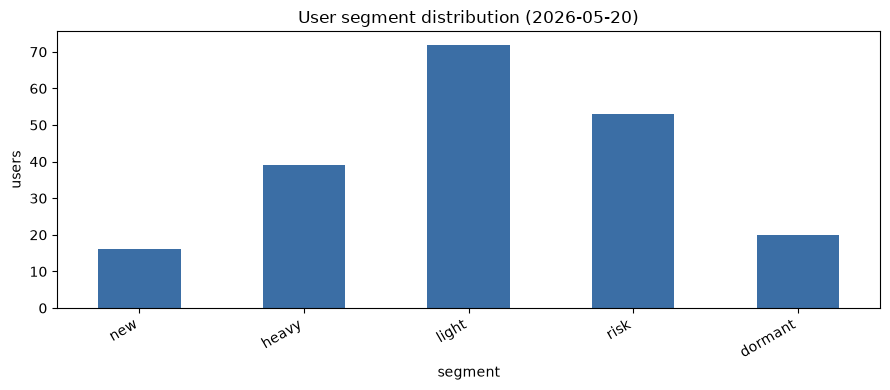

In [10]:
# 일별 세그먼트 분포 (Stock) — 정렬은 pandas reindex 가 담당
dist = con.execute(f"""
SELECT user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '{TARGET}'
GROUP BY user_seg
""").df().set_index("user_seg").reindex(SEG_ORDER)
display(dist)

ax = dist["users"].plot.bar(figsize=(9, 4), color="#3b6ea5")
ax.set_title(f"User segment distribution ({TARGET})")
ax.set_xlabel("segment"); ax.set_ylabel("users")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

이 표는 *오늘* 우리 서비스의 유저들이 어디에 모여 있는지를 보여주는
횡단면(cross-section)입니다. 마트에는 한 달치가 들어 있으니 `target_date` 를 바꿔가며 같은 쿼리를 돌려 보면 세그먼트 구성이 어떻게 달라지는지
관찰할 수 있습니다. 가령 heavy의 절대 수가 줄고 있는데 light가 같이 늘고
있다면, 헤비 유저의 이탈이 서서히 진행되고 있다는 신호로 읽을 수 있겠죠.

### 3.2. Flow - 세그먼트 전이 행렬 확인하기

Stock 만 봐서는, heavy 의 수가 어제와 비슷하게 유지된다고 해도 그게 그대로 남은
유저인지 빠진 자리를 다른 유저가 채운 건지 구별할 수 없습니다. 그 차이를 보려면 세그먼트
전이 행렬을 만들어서 보는 게 간편합니다. 다행히 우리가 만든 데이터 마트에는 그 정보가
이미 들어 있습니다 — 어제(`user_seg_from`)를 행, 오늘(`user_seg`)을 열로 펼치면
전이 행렬이 됩니다.

In [11]:
# 세그먼트 전이 (Flow): 어제(user_seg_from) → 오늘(user_seg)
trans = con.execute(f"""
SELECT user_seg_from, user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '{TARGET}'
  AND user_seg_from IS NOT NULL   -- 오늘 처음 가입한 유저(어제 NULL)는 제외
GROUP BY user_seg_from, user_seg
""").df()

order = SEG_ORDER
pivot = (trans.pivot(index="user_seg_from", columns="user_seg", values="users")
              .reindex(index=order, columns=order))
pivot.fillna(0).astype(int)

user_seg,new,heavy,light,risk,dormant
user_seg_from,,,,,
new,6,1,1,0,0
heavy,0,35,3,0,0
light,0,3,67,4,0
risk,0,0,1,49,1
dormant,0,0,0,0,19


이 행렬을 히트맵으로 그리면 전이가 어디에 몰려 있는지 한눈에 들어옵니다.

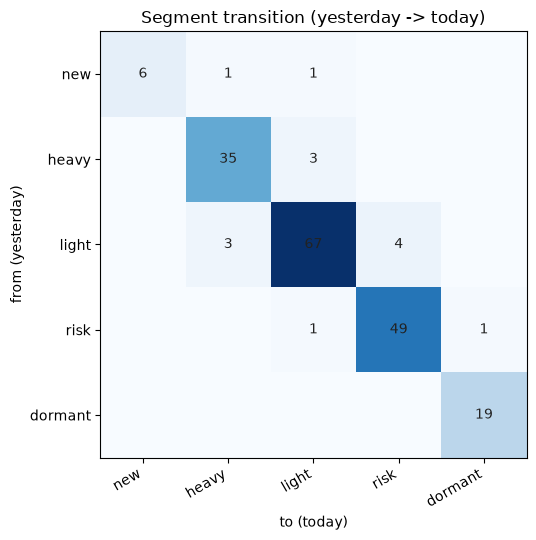

In [12]:
# 전이 행렬 히트맵
m = pivot.values.astype(float)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.nan_to_num(m), cmap="Blues")
ax.set_xticks(range(len(order)), order, rotation=30, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("to (today)"); ax.set_ylabel("from (yesterday)")
for i in range(len(order)):
    for j in range(len(order)):
        if not np.isnan(m[i, j]):
            ax.text(j, i, int(m[i, j]), ha="center", va="center", color="#222")
ax.set_title("Segment transition (yesterday -> today)")
plt.tight_layout(); plt.show()

행과 열은 new 를 맨 앞에 두고, 그 뒤로 활동성이 높은 순(heavy)에서 낮은 순(dormant)으로 정렬되어
있습니다. 어제 new 였던 8명 중 6명은 아직 첫 주 안에 있어 new 에 남았고,
8일째를 맞은 2명은 heavy 와 light 로 한 명씩 안착했습니다(New Activation). risk 로 빠진 유저(New Loss)는
이날 없었네요. 한편 오늘 막 가입한 10명은 어제 세그먼트가 없어서 이 행렬에서는 빠져 있는데요.
그래서 new 열의 합(6명)이 Stock의 new(16명)보다 작습니다. 나머지 네 행은 아래와 같이 세 가지
방향으로 읽어서 해석하면 됩니다.

1. **대각선**: 어제와 오늘의 세그먼트가 같은 유저들. 안정적으로 유지되고 있음을 의미.
2. **대각선 위쪽** (같은 행에서 오른쪽 셀): 활동성이 떨어진 유저들
   (예: heavy → light, light → risk). 이탈 징후로 모니터링해야 할 영역.
3. **대각선 아래쪽** (같은 행에서 왼쪽 셀): 활동성이 더 높아진 유저들
   (예: light → heavy, risk → light). 긍정적 전이로 볼 수 있는 영역.

### 3.3. 비율 지표 생성하기

전이 행렬에서 여러 가지 의미 있는 비율 지표들을 뽑아낼 수 있습니다. 몇 가지 예시를 들면
아래와 같습니다.

1. **HURR (Heavy → Heavy)**: Heavy 유저의 유지율
2. **CURR (Heavy + Light → Heavy + Light)**: Heavy+Light 유저의 유지율
3. **Heavy Loss (Heavy → Light)**: Heavy 에서 Light 유저로 전이된 비율
4. **Light Loss (Light → Risk)**: Light 에서 Risk 유저로 전이된 비율
5. **Reactivation (Risk → Light)**: Risk 에서 Light 유저로 전이된 비율

heavy·light 를 묶은 `current` 는 앞으로도 계속 쓰게 되므로, SQL에 끼워 넣을 문자열 상수로
정의해 둡니다.


In [13]:
current = "('heavy', 'light')"   # 현재 활동 유저 = heavy + light

# 분모가 0이 되는 경우를 막기 위해 nullif(..., 0) 으로 감싼다.
kpi = con.execute(f"""
SELECT
  round(100.0 * count_if(user_seg_from = 'heavy' AND user_seg = 'heavy')
    / nullif(count_if(user_seg_from = 'heavy'), 0), 1) AS hurr_pct,
  round(100.0 * count_if(user_seg_from IN {current} AND user_seg IN {current})
    / nullif(count_if(user_seg_from IN {current}), 0), 1) AS curr_pct,
  round(100.0 * count_if(user_seg_from = 'heavy' AND user_seg = 'light')
    / nullif(count_if(user_seg_from = 'heavy'), 0), 1) AS heavy_loss_pct,
  round(100.0 * count_if(user_seg_from = 'light' AND user_seg = 'risk')
    / nullif(count_if(user_seg_from = 'light'), 0), 1) AS light_loss_pct,
  round(100.0 * count_if(user_seg_from = 'risk' AND user_seg = 'light')
    / nullif(count_if(user_seg_from = 'risk'), 0), 1) AS reactivation_pct
FROM mart_user_segment
WHERE target_date = DATE '{TARGET}';
""").df()
kpi.T.rename(columns={0: "pct"})

,pct
hurr_pct,92.1
curr_pct,96.4
heavy_loss_pct,7.9
light_loss_pct,5.4
reactivation_pct,2.0


각 숫자가 어떤 의미를 가지고 있는지를 다시 한번 정리하면 다음과 같습니다.

| 지표 | 의미 |
| :-- | :-- |
| HURR 92.1% | 어제 heavy 였던 유저 중 92.1%가 오늘도 heavy (유지) |
| CURR 96.4% | 어제 heavy·light 였던 핵심 활동 유저 중 96.4%가 오늘도 동일하게 남아 있음 |
| Heavy Loss 7.9% | 어제 heavy 였던 유저 중 7.9%가 light 로 내려감 |
| Light Loss 5.4% | 어제 light 였던 유저 중 5.4%가 risk 로 이탈 |
| Reactivation 2.0% | 어제 risk 였던 유저 중 2.0%가 다시 light 로 복귀 |

이처럼 쿼리 한 번으로 다양한 비율 지표를 동시에 추출할 수 있습니다. 이러한 지표들을
일별로 차곡차곡 쌓아두면, 단순한 DAU 트렌드와는 비교할 수 없는 해상도로 서비스의 건강
상태를 모니터링할 수 있게 됩니다. 여기서 유의해야 하는 점은, 비율 지표를 해석할 때
**분모의 크기**를 반드시 함께 봐야 한다는 점입니다. 가령 위 예시에서 Reactivation 2.0%는
risk 유저 51명 중 단 1명이 돌아온 결과인데요. 애초에 인원이 적은 세그먼트의 비율은 한두
명만 움직여도 수치가 크게 출렁일 수 있습니다. 그래서 실무에서는 비율 지표를 확인할 때
분모(세그먼트 규모)를 나란히 표기하거나, 하루치가 아니라 일정 기간을 누적해 분모를 키운
뒤 해석하는 편이 보다 안전합니다.

## 실습 4. N일 후 세그먼트 변화 추적

여기까지의 분석은 모두 어제와 오늘, 즉 1일 단위의 변화를 들여다보는 데 집중했습니다.
1일 단위는 마트 갱신 주기와 잘 맞고 즉시성이 높다는 장점이 있지만, 막상 들여다보면 변화의
폭이 너무 작아서 의미 있는 패턴이 잘 드러나지 않는다는 단점도 있습니다. 어제 heavy였던
유저가 오늘도 heavy일 확률이 거의 90%를 웃돌다 보니, HURR 92.1%라는 숫자만으로는 우리
서비스의 헤비 유저 충성도가 정말로 견고한 건지 가늠하기 어렵습니다.

이때 시간 축을 좀 더 길게 잡고 패턴을 살펴보면 세그먼트 간의 전이를 파악하는 데 도움이
됩니다. 예를 들면 30일 전에 heavy 였던 유저들이 오늘 어떤 세그먼트로 나뉘어져 있는지를 본다든가,
30일 전에 new 였던 유저가 오늘은 어디에 있는지를 보는 식입니다.

실습 2에서 만든 마트에는 이미 한 달치(2026-04-20 ~ 2026-05-20, 31일)가 들어 있으므로, `user_id` 기반의 self-join으로 30일 전 세그먼트와 오늘 세그먼트를 바로 이어서 확인할 수 있습니다. 운영 환경에서 마트가 매일 쌓인 상태를 그대로 흉내 낸 셈입니다.

> **[내 데이터 적용]** 60·90일처럼 더 긴 간격을 추적하려면 실습 2의 날짜 목록 시작일을
> 그만큼 앞당겨 마트를 먼저 더 쌓습니다.

이제 두 시점(30일 전 · 오늘)을 `user_id` 로 self-join 하면, 30일 전 **heavy** 유저가 오늘
어느 세그먼트로 흩어졌는지가 한 표로 나옵니다.

,seg_30days_ago,seg_today,users,pct
0,heavy,heavy,25,55.6
1,heavy,light,12,26.7
2,heavy,risk,8,17.8


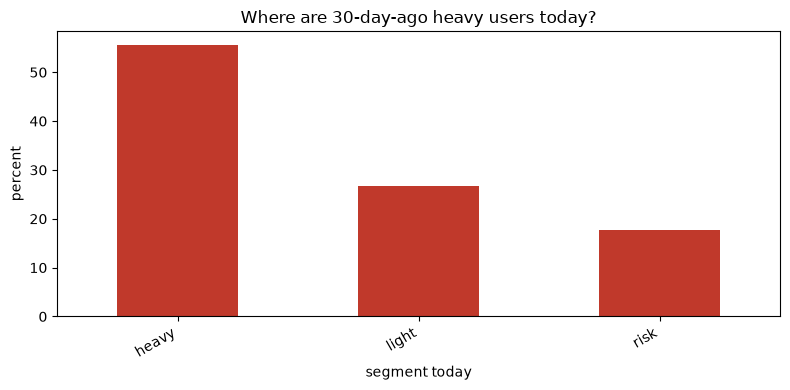

In [14]:
# 30일 전 heavy 유저가 오늘은 어디에 있는가
nday_query = """
SELECT
  past.user_seg AS seg_30days_ago,
  curr.user_seg AS seg_today,
  count(*) AS users,
  round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
FROM mart_user_segment AS past
LEFT JOIN mart_user_segment AS curr
  ON past.user_id = curr.user_id
 AND curr.target_date = DATE '{target}'
WHERE past.target_date = DATE '{target}' - INTERVAL 30 DAY
  AND past.user_seg = '{seg}'
GROUP BY past.user_seg, curr.user_seg
ORDER BY users DESC;
"""
nday = con.execute(nday_query.format(seg="heavy", target=TARGET)).df()
display(nday)

ax = nday.set_index("seg_today")["pct"].plot.bar(figsize=(8, 4),
                                                 color="#c0392b")
ax.set_title("Where are 30-day-ago heavy users today?")
ax.set_xlabel("segment today"); ax.set_ylabel("percent")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

30일 전 heavy 유저의 절반 가까이가 다른 세그먼트로 흩어졌습니다. 이걸 **같은 HURR 기준**으로
1일 변화와 나란히 놓고 비교해 보겠습니다 — 둘 다 *heavy 유지율*입니다.

In [15]:
# 같은 'heavy 유지율(HURR)' 을 1일 / 30일 두 시간 축으로 비교
con.execute(f"""
WITH one_day AS (    -- 어제 heavy → 오늘 heavy
  SELECT round(100.0 * count_if(user_seg_from = 'heavy' AND user_seg = 'heavy')
    / nullif(count_if(user_seg_from = 'heavy'), 0), 1) AS hurr_pct
  FROM mart_user_segment
  WHERE target_date = DATE '{TARGET}'
),
thirty_day AS (      -- 30일 전 heavy → 오늘 heavy
  SELECT round(100.0 * count_if(curr.user_seg = 'heavy')
    / nullif(count(*), 0), 1) AS hurr_pct
  FROM mart_user_segment AS past
  LEFT JOIN mart_user_segment AS curr
    ON past.user_id = curr.user_id AND curr.target_date = DATE '{TARGET}'
  WHERE past.target_date = DATE '{TARGET}' - INTERVAL 30 DAY
    AND past.user_seg = 'heavy'
)
SELECT '1일 (어제 → 오늘)'     AS horizon, hurr_pct FROM one_day
UNION ALL
SELECT '30일 (30일 전 → 오늘)', hurr_pct FROM thirty_day
""").df()

,horizon,hurr_pct
0,1일 (어제 → 오늘),92.1
1,30일 (30일 전 → 오늘),55.6


같은 쿼리의 출발 세그먼트만 `new` 로 바꾸면, **30일 전에 가입 첫 주를 보내고 있던 유저가
오늘 어디에 있는가**가 나옵니다. 1일 단위의 New Activation 이 ‘8일째에 어디로 갔나’를 본다면,
이 표는 한 달 뒤까지 살아남았는지를 보여 줍니다.


In [16]:
# 30일 전 new 유저가 오늘은 어디에 있는가 — 신규 유저의 N일 안착
nday_new = con.execute(nday_query.format(seg="new", target=TARGET)).df()
nday_new

,seg_30days_ago,seg_today,users,pct
0,new,light,6,60.0
1,new,dormant,2,20.0
2,new,heavy,1,10.0
3,new,risk,1,10.0


1일 기준으로는 heavy 유저의 **92.1%**가 다음 날에도 heavy로 남지만, 같은 heavy 그룹을 **30일**
기준으로 보면 그 비율이 **55.6%**까지 떨어집니다. 매일의 작은 이탈이 한 달 동안 누적되면서
30일 전 heavy 유저의 절반 가까이가 light·risk로 흩어진 셈입니다. 1일 HURR이 90%를
넘는다고 안심할 게 아니라, 더 긴 시간 축의 유지율을 함께 봐야 헤비 유저층의 진짜 견고함을
가늠할 수 있습니다.

신규 유저 쪽도 마찬가지입니다. 30일 전 가입 첫 주를 보내던 new 유저 10명 가운데 한 달 뒤에도
heavy·light 로 남은 사람은 7명이고, 나머지 3명은 risk·dormant 로 빠졌습니다. 1일 단위의 New
Activation 이 8일째의 갈림길을 보여 준다면, 이 표는 그 뒤로도 습관이 붙었는지를 보여 줍니다.
`nday_query` 의 `INTERVAL 30 DAY` 를 7이나 14로 바꾸면 다른 시간 축의 변화도 곧바로 볼 수
있습니다. 60일·90일처럼 더 긴 간격을 보려면 실습 2의 날짜 목록 시작일을 그만큼 앞당겨
마트를 먼저 더 쌓아야 합니다. (참고로, 1일 유지율을 N번 곱해서 장기 유지율을 계산하면 안
됩니다. light로 내려갔다가 다시 heavy로 올라오는 케이스를 놓치기 때문이죠.)

매일 적재된 마트 한 장으로 단기 KPI(실습 3)부터 N일 누적 변화(실습 4)까지 같은 구조 위에서
뽑아낼 수 있다는 것이 이 마트의 힘입니다.